# Normalized Data Exploration
This notebook provides:
- Document counts by collection, tier, and phase
- Text quality metrics (word count, character distribution)
- Extraction mode breakdown (article vs fallback)
- Fetch status health check
- Top domains per tier and phase

In [1]:
import json
from pathlib import Path
from collections import Counter, defaultdict
from urllib.parse import urlparse

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# ----- Viridis aesthetic -----
palette = sns.color_palette("rocket", n_colors=7)

sns.set_style("whitegrid", {
    "axes.facecolor": "#ffffff",
    "figure.facecolor": "#ffffff",
    "grid.color": "#e0e0e0",
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

sns.set_palette(palette)

sns.set_context("notebook", font_scale=1.3, rc={
    "lines.linewidth": 2,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
})

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

In [2]:
# Paths and config
from config import PROCESSED_DIR, COVID_COLLECTIONS, PHASES_BY_NAME

NORMALIZED_DIR = PROCESSED_DIR / "normalized"
print(f"Normalized dir: {NORMALIZED_DIR}")

Normalized dir: /home/ala-adn/code/credleaf/data/processed/normalized


In [3]:
def load_normalized_docs(normalized_dir: Path) -> list[dict]:
    """Load all normalized JSONL files into a flat list."""
    docs = []
    for jsonl_path in sorted(normalized_dir.rglob("*.jsonl")):
        print(f"Loading {jsonl_path.relative_to(PROCESSED_DIR)}")
        with jsonl_path.open("r", encoding="utf-8") as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                docs.append(json.loads(line))
    return docs

docs = load_normalized_docs(NORMALIZED_DIR)
print(f"\nLoaded {len(docs)} documents")

Loading normalized/13529/P1_global_onset.jsonl
Loading normalized/13529/P2_pre_vaccine.jsonl
Loading normalized/13529/P3_vaccine_rollout.jsonl
Loading normalized/13529/P4_delta_wave.jsonl
Loading normalized/13529/P5_omicron_wave.jsonl
Loading normalized/13529/P6_transition_end.jsonl
Loading normalized/13559/P1_first_wave.jsonl
Loading normalized/13559/P1_global_onset.jsonl
Loading normalized/13559/P2_pre_vaccine.jsonl
Loading normalized/13559/P3_vaccine_rollout.jsonl
Loading normalized/13559/P4_delta_wave.jsonl
Loading normalized/13559/P5_omicron_wave.jsonl
Loading normalized/13559/P6_transition_end.jsonl

Loaded 10784 documents


In [4]:
# Build dataframe for easier analysis
df = pd.DataFrame(docs)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

Shape: (10784, 17)

Columns: ['title', 'text', 'language', 'publish_date', 'extraction_mode', 'collection_id', 'seed_id', 'seed_url', 'phase', 'capture_timestamp', 'capture_url', 'digest', 'fetched_at', 'fetch_status', 'error', 'word_count', 'char_count']

Data types:
title                  str
text                   str
language               str
publish_date           str
extraction_mode        str
collection_id        int64
seed_id              int64
seed_url               str
phase                  str
capture_timestamp      str
capture_url            str
digest                 str
fetched_at             str
fetch_status           str
error                  str
word_count           int64
char_count           int64
dtype: object


In [5]:
# Add credibility tier lookup
from credibility.registry import CredibilityRegistry, normalize_host

# Try to load pre-built registry if available, otherwise mark as unknown
registry_path = PROCESSED_DIR / "credibility.json"
if registry_path.exists():
    registry = CredibilityRegistry.load(registry_path)
    print(f"Loaded credibility registry: {registry}")
else:
    registry = CredibilityRegistry()
    print("No credibility registry found; using collection tier fallback")

# Fallback: use collection tier from config
def get_tier(row):
    tier = registry.lookup(row["seed_url"])
    if tier == "unknown":
        # Fall back to collection tier from config
        coll = COVID_COLLECTIONS.get(row["collection_id"])
        tier = coll.credibility_tier if coll else "unknown"
    return tier

df["tier"] = df.apply(get_tier, axis=1)
print(f"\nTier distribution:\n{df['tier'].value_counts()}")

Loaded credibility registry: CredibilityRegistry(low=99, authoritative=39, mixed=9042)

Tier distribution:
tier
mixed            4865
low              4786
authoritative    1133
Name: count, dtype: int64


## 1. Overview Statistics

In [6]:
# Document count by collection and phase
print("\n=== Document Counts ===")
print(f"\nTotal documents: {len(df)}")
print(f"Unique collections: {df['collection_id'].nunique()}")
print(f"Unique phases: {df['phase'].nunique()}")

print(f"\nBy collection:")
for cid, count in df['collection_id'].value_counts().sort_index().items():
    coll = COVID_COLLECTIONS.get(cid)
    coll_name = coll.name if coll else f"Unknown {cid}"
    print(f"  {cid} ({coll_name}): {count}")

print(f"\nBy phase:")
for phase, count in df['phase'].value_counts().items():
    print(f"  {phase}: {count}")

print(f"\nBy tier:")
for tier, count in df['tier'].value_counts().items():
    pct = 100 * count / len(df)
    print(f"  {tier}: {count} ({pct:.1f}%)")


=== Document Counts ===

Total documents: 10784
Unique collections: 2
Unique phases: 7

By collection:
  13529 (Novel Coronavirus (COVID-19)): 6000
  13559 (False Coronavirus (COVID-19) Information): 4784

By phase:
  P1_global_onset: 2000
  P2_pre_vaccine: 2000
  P3_vaccine_rollout: 2000
  P4_delta_wave: 2000
  P5_omicron_wave: 1596
  P6_transition_end: 1002
  P1_first_wave: 186

By tier:
  mixed: 4865 (45.1%)
  low: 4786 (44.4%)
  authoritative: 1133 (10.5%)


## 2. Fetch & Extraction Health

In [7]:
# Fetch status breakdown
print("\n=== Fetch Status ===")
status_counts = df['fetch_status'].value_counts()
for status, count in status_counts.items():
    pct = 100 * count / len(df)
    print(f"  {status}: {count} ({pct:.1f}%)")

# Extraction mode breakdown
ok_df = df[df['fetch_status'] == 'ok']
print(f"\n=== Extraction Mode (n={len(ok_df)}) ===")
mode_counts = ok_df['extraction_mode'].value_counts()
for mode, count in mode_counts.items():
    pct = 100 * count / len(ok_df)
    print(f"  {mode}: {count} ({pct:.1f}%)")

# Error summary
errors_df = df[df['fetch_status'] != 'ok']
if len(errors_df) > 0:
    print(f"\n=== Sample Errors ===")
    for idx, (_, row) in enumerate(errors_df.head(5).iterrows()):
        err = row['error'] if pd.notna(row.get('error')) else 'N/A'
        print(f"  {row['fetch_status']}: {str(err)[:80]}")


=== Fetch Status ===
  ok: 10464 (97.0%)
  fetch_failed: 181 (1.7%)
  extract_failed: 139 (1.3%)

=== Extraction Mode (n=10464) ===
  article: 10458 (99.9%)
  fallback_html2txt: 6 (0.1%)

=== Sample Errors ===
  fetch_failed: Client error '429 Too Many Requests' for url 'https://wayback.archive-it.org/135
  fetch_failed: Client error '429 Too Many Requests' for url 'https://wayback.archive-it.org/135
  fetch_failed: Client error '429 Too Many Requests' for url 'https://wayback.archive-it.org/135
  fetch_failed: Server disconnected without sending a response.
  extract_failed: N/A


## 3. Text Quality Metrics

In [8]:
# Only analyze successful extractions
ok_df = df[df['fetch_status'] == 'ok'].copy()

print(f"\n=== Text Length (n={len(ok_df)}) ===")
print(f"\nWord count:")
print(f"  Mean: {ok_df['word_count'].mean():.0f}")
print(f"  Median: {ok_df['word_count'].median():.0f}")
print(f"  Std: {ok_df['word_count'].std():.0f}")
print(f"  Min: {ok_df['word_count'].min()}")
print(f"  Max: {ok_df['word_count'].max()}")

print(f"\nCharacter count:")
print(f"  Mean: {ok_df['char_count'].mean():.0f}")
print(f"  Median: {ok_df['char_count'].median():.0f}")
print(f"  Std: {ok_df['char_count'].std():.0f}")
print(f"  Min: {ok_df['char_count'].min()}")
print(f"  Max: {ok_df['char_count'].max()}")


=== Text Length (n=10464) ===

Word count:
  Mean: 616
  Median: 217
  Std: 3791
  Min: 1
  Max: 183801

Character count:
  Mean: 4026
  Median: 1375
  Std: 26043
  Min: 7
  Max: 1388368


In [9]:
# remove outliers
df_no_outliers = ok_df[ok_df['word_count'] < ok_df['word_count'].mean() + ok_df['word_count'].std()]

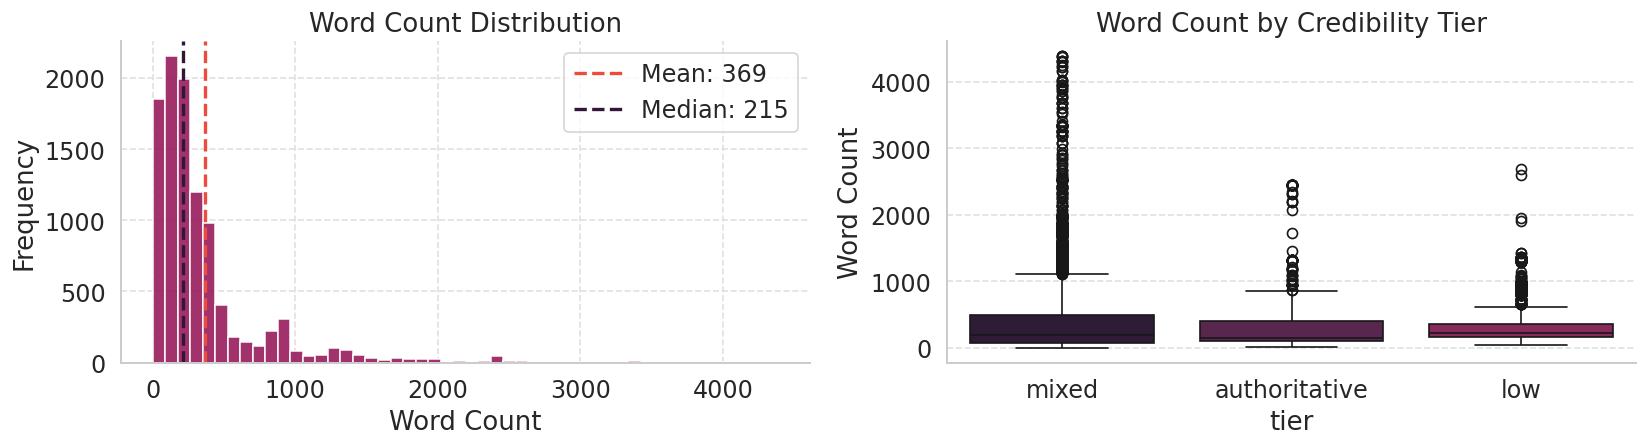


Word count by tier:
                count        mean         std   min    25%    50%    75%  \
tier                                                                       
authoritative   993.0  354.712991  510.655241  10.0   99.0  143.0  401.0   
low            4779.0  304.818372  244.744466  43.0  168.5  228.0  357.0   
mixed          4527.0  439.157720  623.602168   1.0   78.0  198.0  492.0   

                  max  
tier                   
authoritative  2448.0  
low            2691.0  
mixed          4390.0  


In [10]:
# Visualize word count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df_no_outliers['word_count'], bins=50, color=palette[2], edgecolor='white', alpha=0.9)
axes[0].axvline(df_no_outliers['word_count'].mean(), color=palette[4], linestyle='--', linewidth=2,
                label=f"Mean: {df_no_outliers['word_count'].mean():.0f}")
axes[0].axvline(df_no_outliers['word_count'].median(), color=palette[0], linestyle='--', linewidth=2,
                label=f"Median: {df_no_outliers['word_count'].median():.0f}")
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Word Count Distribution')
axes[0].legend()

# Box plot by tier (uses global viridis palette)
sns.boxplot(data=df_no_outliers, x='tier', y='word_count', ax=axes[1], palette=palette)
axes[1].set_title('Word Count by Credibility Tier')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.show()

print("\nWord count by tier:")
print(df_no_outliers.groupby('tier')['word_count'].describe())

## 4. Temporal Patterns

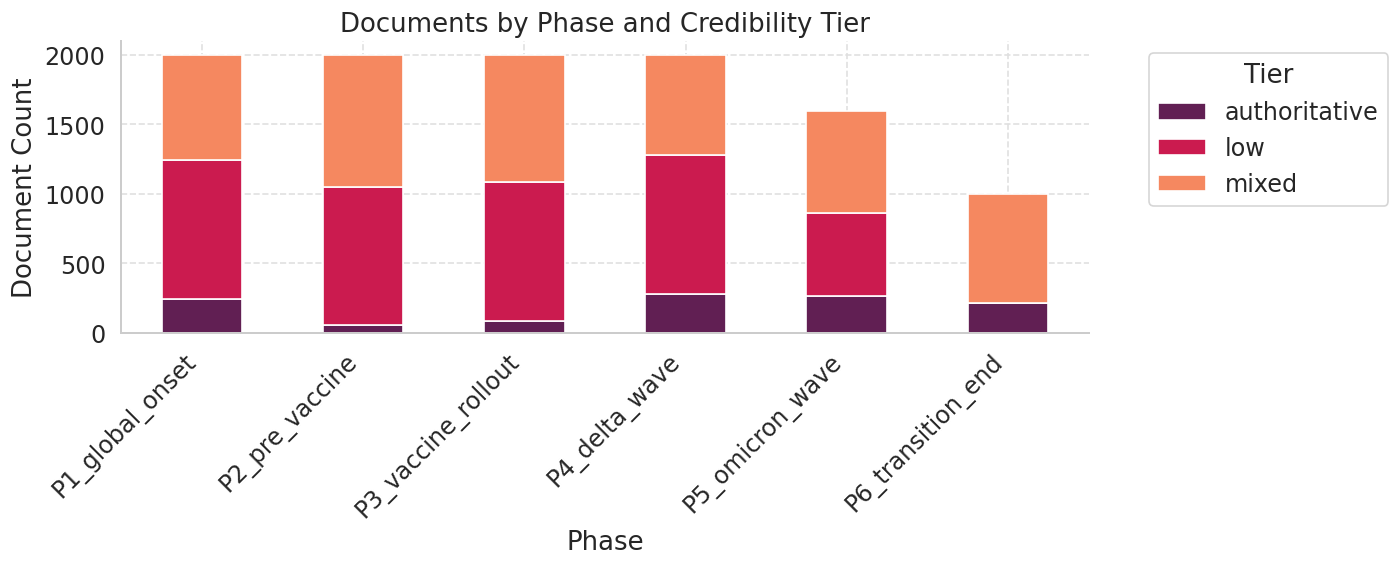


Document counts by phase and tier:
tier                authoritative   low  mixed
phase                                         
P1_global_onset               242  1002    756
P2_pre_vaccine                 52  1000    948
P3_vaccine_rollout             84  1000    916
P4_delta_wave                 277  1000    723
P5_omicron_wave               263   596    737
P6_transition_end             215     2    785


In [11]:
# Phase progression
phase_order = [p.name for p in PHASES_BY_NAME.values()]
df['phase_num'] = df['phase'].map({p: i for i, p in enumerate(phase_order)})

fig, ax = plt.subplots(figsize=(12, 5))

# Group by phase and tier
phase_tier_counts = df.groupby(['phase', 'tier']).size().unstack(fill_value=0)
# Reorder by phase
phase_tier_counts = phase_tier_counts.loc[phase_order]

n_tiers = len(phase_tier_counts.columns)
phase_tier_counts.plot(
    kind='bar', stacked=True, ax=ax,
    color=sns.color_palette("rocket", n_colors=n_tiers),
    edgecolor='white',
)
ax.set_xlabel('Phase')
ax.set_ylabel('Document Count')
ax.set_title('Documents by Phase and Credibility Tier')
ax.legend(title='Tier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nDocument counts by phase and tier:")
print(phase_tier_counts)

### Granular capture-date distribution
Phase buckets compress 3+ years of activity into 8 bins; here is the same data resolved to month and week.

In [12]:
df

,title,text,language,publish_date,extraction_mode,collection_id,seed_id,seed_url,phase,capture_timestamp,capture_url,digest,fetched_at,fetch_status,error,word_count,char_count,tier,phase_num
0,Accueil,Editorial\n- More than 60% of infectious disea...,en,2012-08-04,article,13529,2147692,http://coronavirus.fr/,P1_global_onset,20200221192410,http://coronavirus.fr/,33DKLKKX5XNGTC6CZRPCJBJBOGTKFWH2,2026-05-11T21:30:19.974798Z,ok,NaN,1306,8667,mixed,0.0
1,Accueil,Editorial\n- More than 60% of infectious disea...,en,2012-08-04,article,13529,2147692,http://coronavirus.fr/,P1_global_onset,20200221192458,http://coronavirus.fr/,LGOY2ETFCD76MKR37PZZSQQUPUT5YQXY,2026-05-11T21:30:20.052351Z,ok,NaN,1306,8667,mixed,0.0
2,Accueil,Editorial\n- More than 60% of infectious disea...,en,2020-04-10,article,13529,2147692,http://coronavirus.fr/,P1_global_onset,20200805215650,http://coronavirus.fr/,TMAIIORFGJVGSD4JG2L7DDO2TLBFGANN,2026-05-11T21:30:20.160314Z,ok,NaN,1306,8667,mixed,0.0
3,Accueil,Editorial\n- More than 60% of infectious disea...,en,2020-04-10,article,13529,2147692,http://coronavirus.fr/,P1_global_onset,20200806023300,http://coronavirus.fr/,AVIA44S63XUAK26ZXUA2MLMVYD3DH7XS,2026-05-11T21:30:20.284052Z,ok,NaN,1306,8667,mixed,0.0
4,Accueil,Editorial\n- More than 60% of infectious disea...,en,2020-04-10,article,13529,2147692,http://coronavirus.fr/,P1_global_onset,20201026223333,http://coronavirus.fr/,SONIFBS5YUT7JX2HLAOQOOQJHVJPO77N,2026-05-11T21:30:20.391751Z,ok,NaN,1306,8667,mixed,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10779,Suspect Arrested Near Kavanaugh House Charged ...,"""A Glock 17 pistol, ammunition, a knife, zip t...",en,2022-06-08,article,13559,2153766,http://zerohedge.com/,P5_omicron_wave,20220609093818,https://www.zerohedge.com/,EK5HQI6KHBQVVPCL5UVUHQMGSURI4EMD,2026-05-11T08:04:59.169537Z,ok,NaN,332,1998,low,4.0
10780,Bye Felicia: WaPo Fires Triggered Reporter Ove...,The last thing this market needed was to hear....,en,2022-06-09,article,13559,2153766,http://zerohedge.com/,P5_omicron_wave,20220609223604,https://www.zerohedge.com/,UJ7YFYN4NWHIPZN3P6Q24OELHK5EYQ3B,2026-05-11T08:05:13.220940Z,ok,NaN,212,1298,low,4.0
10781,"A Shocked Wall Street Reacts To Today's ""Scary...","""This report ought to be disturbing for Fed of...",en,2022-06-10,article,13559,2153766,http://zerohedge.com/,P5_omicron_wave,20220610195452,https://www.zerohedge.com/,2XAY6U6XU7OWENWE2B4XWFGERPV67BED,2026-05-11T08:05:28.006574Z,ok,NaN,425,2592,low,4.0
10782,The Mind Unleashed,Where is Elon Musk?\nA psychologist visited wi...,en,2022-04-10,article,13559,2153763,http://themindunleashed.com/,P6_transition_end,20220701110349,https://themindunleashed.com/,STQ5KECUMZ2UG7SQBAG6G2MCLJ4H2ILJ,2026-05-11T07:56:03.363024Z,ok,NaN,138,860,low,5.0


Publish date range: 1995-02-02 -> 2026-02-21
Parsed: 10366 / 10784 (96.1%)


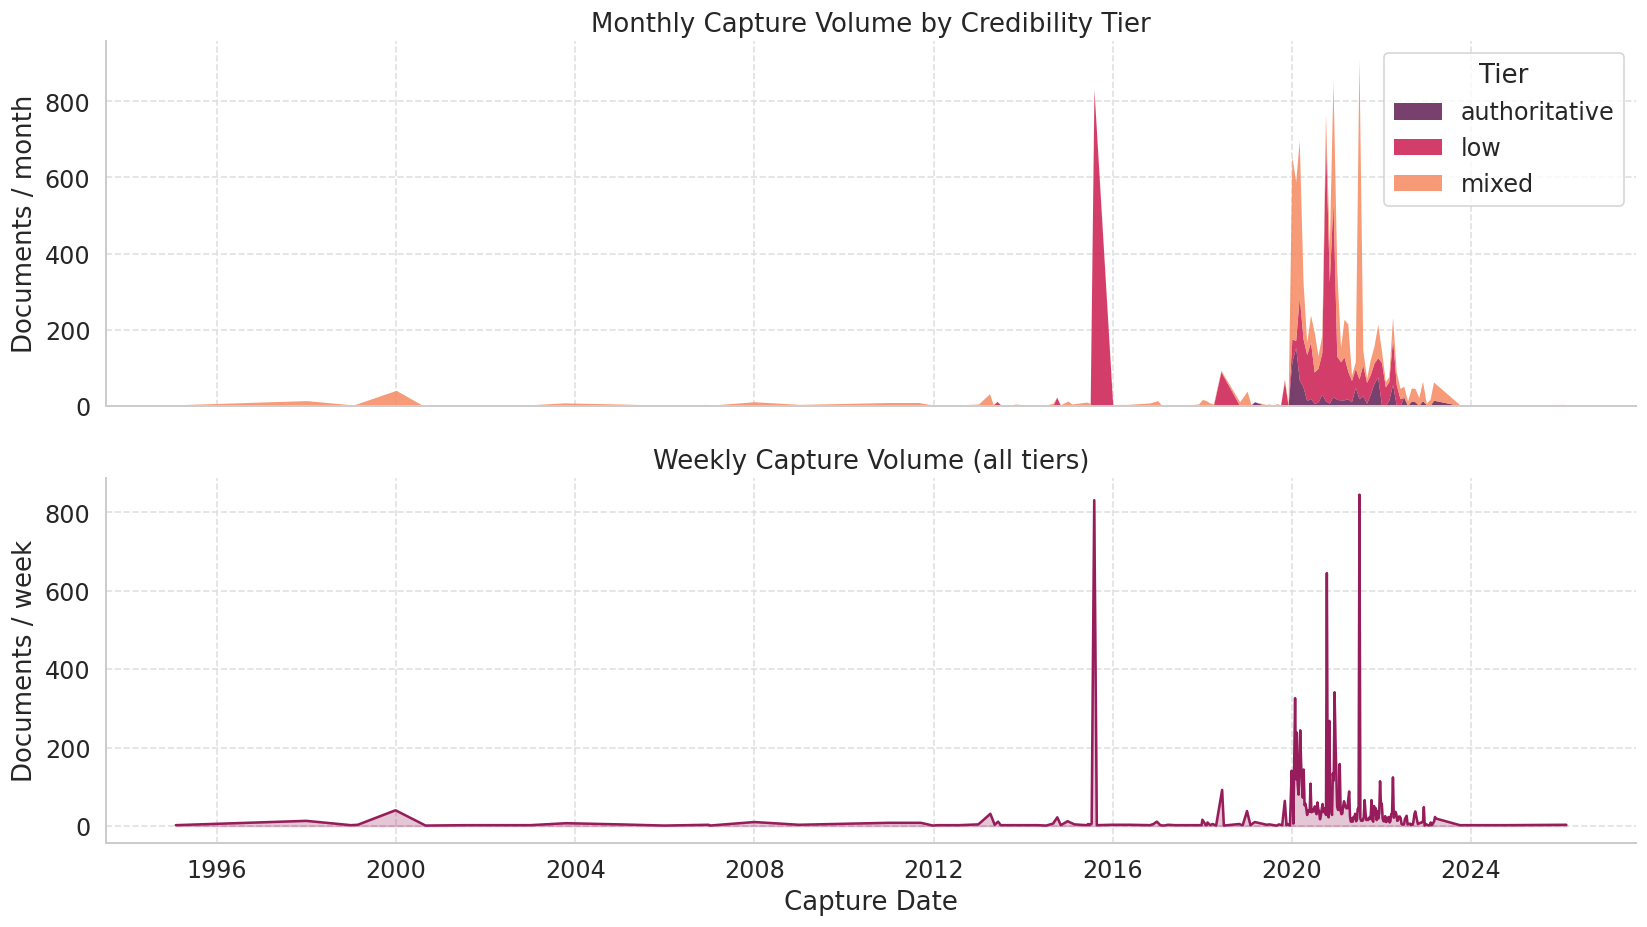


Top capture months:
publish_dt
2021-07    913
2020-12    854
2015-08    833
2020-10    767
2020-03    698
Freq: M, Name: count, dtype: int64


In [13]:
df["publish_dt"] = pd.to_datetime(
    df["publish_date"].astype("string").str.slice(0, 10),
    format="%Y-%m-%d",
    errors="coerce",
)
valid = df.dropna(subset=['publish_dt'])
print(f"Publish date range: {valid['publish_dt'].min().date()} -> {valid['publish_dt'].max().date()}")
print(f"Parsed: {len(valid)} / {len(df)} ({100*len(valid)/len(df):.1f}%)")

# Monthly stacked area by tier
monthly = (valid
    .assign(month=lambda d: d['publish_dt'].dt.to_period('M').dt.to_timestamp())
    .groupby(['month', 'tier']).size().unstack(fill_value=0)
    .sort_index())

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

monthly.plot(
    kind='area', stacked=True, ax=axes[0],
    color=sns.color_palette("rocket", n_colors=monthly.shape[1]),
    alpha=0.85, linewidth=0,
)
axes[0].set_ylabel('Documents / month')
axes[0].set_title('Monthly Capture Volume by Credibility Tier')
axes[0].legend(title='Tier', loc='upper right')

# Weekly line for finer detail
weekly = (valid
    .assign(week=lambda d: d['publish_dt'].dt.to_period('W').dt.start_time)
    .groupby('week').size())
axes[1].plot(weekly.index, weekly.values, color=palette[2], linewidth=1.5)
axes[1].fill_between(weekly.index, weekly.values, color=palette[2], alpha=0.25)
axes[1].set_ylabel('Documents / week')
axes[1].set_xlabel('Capture Date')
axes[1].set_title('Weekly Capture Volume (all tiers)')

plt.tight_layout()
plt.show()

print("\nTop capture months:")
print(valid['publish_dt'].dt.to_period('M').value_counts().head(5))

## 5. Top Domains

In [14]:
# Extract domain from seed_url
def extract_domain(url):
    if not url:
        return None
    parsed = urlparse(url) if '://' in url else urlparse(f'http://{url}')
    hostname = parsed.hostname or parsed.netloc
    return hostname.lower() if hostname else None

df['domain'] = df['seed_url'].apply(extract_domain)

print("\n=== Top 20 Domains (Overall) ===")
top_domains = df['domain'].value_counts().head(20)
for domain, count in top_domains.items():
    tier = df[df['domain'] == domain]['tier'].mode()[0] if len(df[df['domain'] == domain]) > 0 else 'unknown'
    print(f"  {domain}: {count} ({tier})")


=== Top 20 Domains (Overall) ===
  themindunleashed.com: 1421 (low)
  zerohedge.com: 1277 (low)
  www.outbreak.my: 839 (mixed)
  rushlimbaugh.com: 831 (low)
  www.who.int: 367 (authoritative)
  infowars.com: 300 (low)
  www.cdph.ca.gov: 153 (authoritative)
  www.cdc.gov: 145 (authoritative)
  bigleaguepolitics.com: 89 (low)
  www.salute.gov.it: 76 (authoritative)
  www.un.org: 75 (authoritative)
  mercola.com: 65 (low)
  dcclothesline.com: 64 (low)
  www.dsn.gob.es: 63 (authoritative)
  www.niaid.nih.gov: 59 (authoritative)
  covid19.saglik.gov.tr: 58 (authoritative)
  humansarefree.com: 56 (low)
  conspiracy.news: 52 (low)
  sott.net: 50 (low)
  coronavirus.nl: 48 (authoritative)


In [15]:
# Top domains per tier
# https://ucscsciencenotes.com/please-stop-reading-mind-unleashed/
for tier in sorted(df['tier'].unique()):
    tier_df = df[df['tier'] == tier]
    print(f"\n=== Top Domains: {tier} (n={len(tier_df)}) ===")
    top_domains = tier_df['domain'].value_counts().head(10)
    for domain, count in top_domains.items():
        print(f"  {domain}: {count}")


=== Top Domains: authoritative (n=1133) ===
  www.who.int: 367
  www.cdph.ca.gov: 153
  www.cdc.gov: 145
  www.salute.gov.it: 76
  www.un.org: 75
  www.dsn.gob.es: 63
  www.niaid.nih.gov: 59
  covid19.saglik.gov.tr: 58
  coronavirus.nl: 48
  www.canada.ca: 28

=== Top Domains: low (n=4786) ===
  themindunleashed.com: 1421
  zerohedge.com: 1277
  rushlimbaugh.com: 831
  infowars.com: 300
  bigleaguepolitics.com: 89
  mercola.com: 65
  dcclothesline.com: 64
  humansarefree.com: 56
  conspiracy.news: 52
  sott.net: 50

=== Top Domains: mixed (n=4865) ===
  www.outbreak.my: 839
  www.worldometers.info: 45
  weekly.chinacdc.cn: 42
  www.nytimes.com: 40
  jornalacores9.pt: 37
  www.globalhealthnow.org: 36
  www.coronavirus.bs.ch: 35
  coronavirus.gob.mx: 32
  coronavirus.fr: 31
  covid19.kemkes.go.id: 31


## 6. Language Distribution

In [16]:
lang_counts = ok_df['language'].value_counts().head(15)
lang_counts

language
en    8525
pt     369
es     323
fr     168
de     156
cs      97
it      87
nl      62
tr      54
id      53
ar      44
ko      42
ja      40
el      29
sk      24
Name: count, dtype: int64


=== Languages (n=10464) ===
  en: 8525 (81.5%)
  pt: 369 (3.5%)
  es: 323 (3.1%)
  fr: 168 (1.6%)
  de: 156 (1.5%)
  cs: 97 (0.9%)
  it: 87 (0.8%)
  nl: 62 (0.6%)
  tr: 54 (0.5%)
  id: 53 (0.5%)
  ar: 44 (0.4%)
  ko: 42 (0.4%)
  ja: 40 (0.4%)
  el: 29 (0.3%)
  sk: 24 (0.2%)


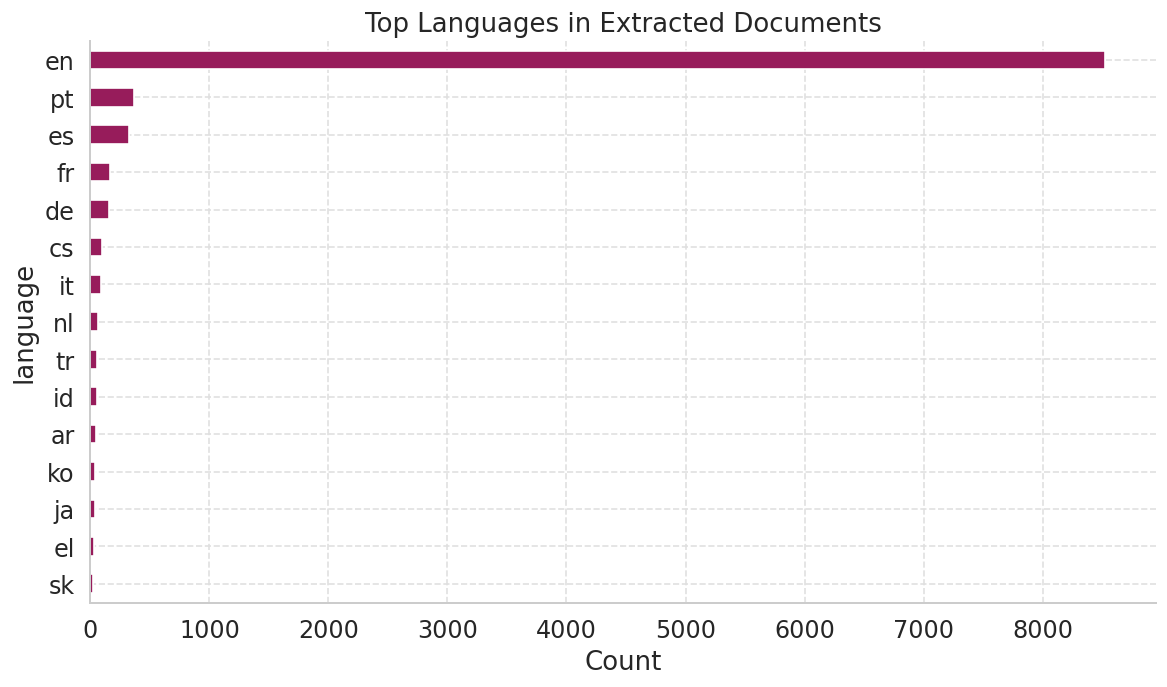

In [17]:
# Language distribution (for successful extractions)
ok_df = df[df['fetch_status'] == 'ok']
print(f"\n=== Languages (n={len(ok_df)}) ===")
lang_counts = ok_df['language'].value_counts().head(15)
for lang, count in lang_counts.items():
    pct = 100 * count / len(ok_df)
    print(f"  {lang}: {count} ({pct:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
lang_counts.plot(kind='barh', ax=ax, color=palette[2], edgecolor='white')
ax.set_xlabel('Count')
ax.set_title('Top Languages in Extracted Documents')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Document Redundancy
Near-duplicate detection via word-shingle MinHash + LSH banding, with exact Jaccard verification at >= 0.9. Reports cluster sizes, redundancy by tier, and the top redundant clusters.

In [18]:
# Near-duplicate detection via word-shingle MinHash + LSH banding
# Confirms candidate pairs by exact Jaccard at THRESHOLD.
import hashlib
import re

K_SHINGLE = 5            # word k-shingle size
N_HASHES  = 128          # MinHash signature length
B_BANDS, R_ROWS = 8, 16  # LSH: 8 bands x 16 rows -> threshold ~= (1/8)^(1/16) ~= 0.876
THRESHOLD = 0.90
PRIME = (1 << 31) - 1    # keeps a*x in int64 range

assert B_BANDS * R_ROWS == N_HASHES

_word_re = re.compile(r"\w+")

def shingles(text, k=K_SHINGLE):
    if not text or pd.isna(text):
        return set()
    tokens = _word_re.findall(text.lower())
    if len(tokens) < k:
        return {hash(tuple(tokens)) & (PRIME - 1)} if tokens else set()
    return {hash(tuple(tokens[i:i + k])) & (PRIME - 1)
            for i in range(len(tokens) - k + 1)}

rng = np.random.default_rng(42)
A_HASH = rng.integers(1, PRIME, size=N_HASHES, dtype=np.int64)
B_HASH = rng.integers(0, PRIME, size=N_HASHES, dtype=np.int64)

def minhash_sig(shingle_set):
    if not shingle_set:
        return np.full(N_HASHES, PRIME, dtype=np.int64)
    s = np.fromiter(shingle_set, dtype=np.int64)
    h = (A_HASH[None, :] * s[:, None] + B_HASH[None, :]) % PRIME
    return h.min(axis=0)

print("Building shingles + MinHash signatures...")
work_df = df[df['fetch_status'] == 'ok'].reset_index(drop=True)
shingle_sets = [shingles(t) for t in work_df['text']]
sigs = np.stack([minhash_sig(s) for s in shingle_sets])
print(f"  signatures: {sigs.shape} | docs: {len(work_df)}")

# LSH banding -> bucket candidates
buckets = defaultdict(list)
for idx, sig in enumerate(sigs):
    for b in range(B_BANDS):
        band = sig[b * R_ROWS:(b + 1) * R_ROWS].tobytes()
        buckets[(b, hashlib.md5(band).digest())].append(idx)

candidates = set()
for ids in buckets.values():
    if len(ids) < 2:
        continue
    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            a, b = sorted((ids[i], ids[j]))
            candidates.add((a, b))
print(f"  candidate pairs from LSH: {len(candidates):,}")

def jaccard(s1, s2):
    if not s1 or not s2:
        return 0.0
    inter = len(s1 & s2)
    return inter / (len(s1) + len(s2) - inter)

dup_pairs = [(i, j) for i, j in candidates
             if jaccard(shingle_sets[i], shingle_sets[j]) >= THRESHOLD]
print(f"  confirmed near-duplicate pairs (Jaccard >= {THRESHOLD}): {len(dup_pairs):,}")

Building shingles + MinHash signatures...
  signatures: (10464, 128) | docs: 10464
  candidate pairs from LSH: 286,667
  confirmed near-duplicate pairs (Jaccard >= 0.9): 279,755


=== Document Redundancy (Jaccard >= 0.9) ===
  Docs analyzed:            10,464
  Singletons (no near-dup): 2,268
  Near-duplicate clusters:  2,145 (containing 8,196 docs)
  Effective unique docs:    4,413
  Redundant docs:           6,051 (57.8%)
  Largest cluster sizes:    [670, 161, 145, 80, 66, 65, 64, 50, 46, 46]

Redundancy by tier:
  authoritative: 761/996 redundant (76.4%)
  low: 2458/4781 redundant (51.4%)
  mixed: 2832/4687 redundant (60.4%)

Top near-duplicate clusters:
  #1 size= 670 | https://www.outbreak.my/ | COVID-19 | Malaysia Outbreak Monitor | Live Updates
  #2 size= 161 | https://www.outbreak.my/ | COVID-19 | Malaysia Outbreak Monitor | Live Updates
  #3 size= 145 | http://zerohedge.com/ | Zerohedge
  #4 size=  80 | http://themindunleashed.com/ | The Mind Unleashed · News - Health - Science - Media - Explo
  #5 size=  66 | http://themindunleashed.com/ | Home · The Mind Unleashed


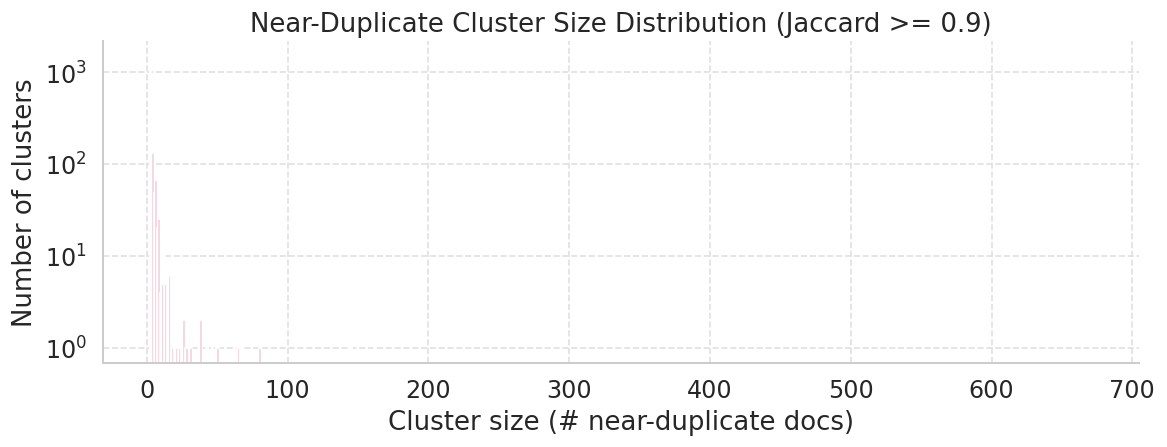

In [19]:
# Cluster near-duplicates (union-find) and report
parent = list(range(len(work_df)))
def _find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
def _union(x, y):
    px, py = _find(x), _find(y)
    if px != py:
        parent[px] = py

for i, j in dup_pairs:
    _union(i, j)

clusters = defaultdict(list)
for i in range(len(work_df)):
    clusters[_find(i)].append(i)

cluster_sizes = sorted((len(c) for c in clusters.values()), reverse=True)
n_total = len(work_df)
n_singletons = sum(1 for s in cluster_sizes if s == 1)
n_dup_clusters = sum(1 for s in cluster_sizes if s > 1)
n_dup_docs = sum(s for s in cluster_sizes if s > 1)
n_redundant = n_dup_docs - n_dup_clusters  # docs that could be dropped (keep one per cluster)

print(f"=== Document Redundancy (Jaccard >= {THRESHOLD}) ===")
print(f"  Docs analyzed:            {n_total:,}")
print(f"  Singletons (no near-dup): {n_singletons:,}")
print(f"  Near-duplicate clusters:  {n_dup_clusters:,} (containing {n_dup_docs:,} docs)")
print(f"  Effective unique docs:    {n_singletons + n_dup_clusters:,}")
print(f"  Redundant docs:           {n_redundant:,} ({n_redundant/n_total*100:.1f}%)")
print(f"  Largest cluster sizes:    {cluster_sizes[:10]}")

# Redundancy by tier
print(f"\nRedundancy by tier:")
for tier in sorted(work_df['tier'].unique()):
    tier_idx = set(work_df.index[work_df['tier'] == tier])
    tier_clusters = [[i for i in c if i in tier_idx] for c in clusters.values()]
    tier_clusters = [c for c in tier_clusters if c]
    tier_total = len(tier_idx)
    tier_redundant = sum(len(c) - 1 for c in tier_clusters if len(c) > 1)
    rate = tier_redundant / tier_total * 100 if tier_total else 0
    print(f"  {tier}: {tier_redundant}/{tier_total} redundant ({rate:.1f}%)")

# Top duplicate clusters with example URL
print(f"\nTop near-duplicate clusters:")
big_clusters = sorted((c for c in clusters.values() if len(c) > 1), key=len, reverse=True)[:5]
for rank, c in enumerate(big_clusters, 1):
    sample_url = work_df.iloc[c[0]]['seed_url']
    sample_title = work_df.iloc[c[0]]['title'] or '(no title)'
    print(f"  #{rank} size={len(c):>4} | {sample_url} | {str(sample_title)[:60]}")

# Plot cluster size distribution
multi = [s for s in cluster_sizes if s > 1]
if multi:
    fig, ax = plt.subplots(figsize=(10, 4))
    bins = np.arange(2, max(multi) + 2)
    ax.hist(multi, bins=bins, color=palette[3], edgecolor='white')
    ax.set_xlabel('Cluster size (# near-duplicate docs)')
    ax.set_ylabel('Number of clusters')
    ax.set_title(f'Near-Duplicate Cluster Size Distribution (Jaccard >= {THRESHOLD})')
    ax.set_yscale('log')
    plt.tight_layout()
    plt.show()

## 7. Sample Document Preview

In [20]:
# Show a few sample documents
sample_df = ok_df.sample(min(3, len(ok_df)), random_state=42)

for idx, (_, row) in enumerate(sample_df.iterrows()):
    print(f"\n{'='*80}")
    print(f"Sample {idx+1}: {row['collection_id']} | {row['phase']} | {row['tier']}")
    print(f"URL: {row['seed_url']}")
    print(f"Title: {row['title'][:100] if row['title'] else 'N/A'}")
    print(f"Word count: {row['word_count']} | Extraction: {row['extraction_mode']}")
    print(f"\nText preview:")
    text = row.get('text', '')[:300]
    print(f"{text}..." if len(text) == 300 else text)


Sample 1: 13559 | P2_pre_vaccine | low
URL: http://biased.news/
Title: Biased News | Biased News – Biased Information
Word count: 930 | Extraction: article

Text preview:
absurd
newsfakes
biased
lies
honest
journalism
12/06/2020
/
JD Heyes
Lawsuit-worthy? YouTube literally announces platform will begin to discriminate against straight white male creators
12/06/2020
/
News Editors
Facebook to now ban ‘false claims’ about coronavirus vaccines
12/05/2020
/
Ramon Tomey
L...

Sample 2: 13559 | P3_vaccine_rollout | low
URL: http://themindunleashed.com/
Title: Home · The Mind Unleashed
Word count: 197 | Extraction: article

Text preview:
A deadly 2020 wildfire in Northern California that killed two people and was one of the largest fires in state history was actually the work of...
Joel Greenberg, the former Florida county tax collector and longtime “wingman” of embattled Rep. Matt Gaetz, admitted in a letter that both he and the di...

Sample 3: 13529 | P4_delta_wave | mixed
URL: https://ww